## Support Vector Classifier Implementation

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Creating Synthetic Datasets 

from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000, n_features=2,
                         n_classes=2,
                           n_clusters_per_class=1, n_redundant=0)

<Axes: xlabel='x1', ylabel='x2'>

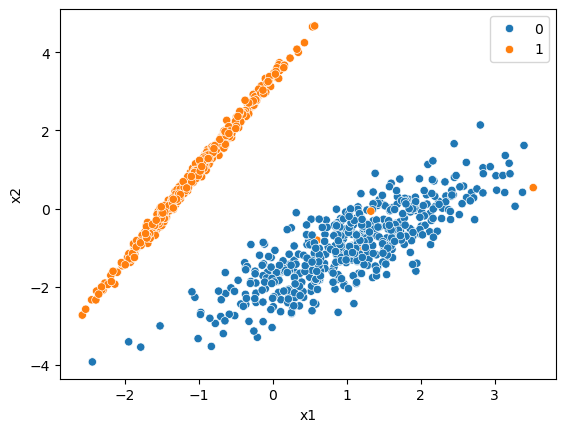

In [15]:
df = pd.DataFrame(X, columns=['x1', 'x2'])

sns.scatterplot(
    x='x1',
    y='x2',
    hue=y,
    data=df
)

In [16]:
df.head()

,x1,x2
0,-1.149758,0.455765
1,-0.099543,3.329317
2,2.002358,-0.076227
3,1.922144,-0.047688
4,0.969051,-0.635728


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=0)

In [22]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')
svc.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
y_pred=svc.predict(X_test)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       130
           1       1.00      0.99      1.00       120

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [26]:
rbf=SVC(kernel='rbf')
rbf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
y_pred1= rbf.predict(X_test)

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],   # ✅ capital C
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}


In [35]:
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    refit=True,
    cv=5,
    verbose=3
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.987 total time=   0.0s
[CV 2/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.987 total time=   0.0s
[CV 3/5] END .C=0.1, gamma=scale, kernel=linear;, score=1.000 total time=   0.0s
[CV 4/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.987 total time=   0.0s
[CV 5/5] END .C=0.1, gamma=scale, kernel=linear;, score=1.000 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.987 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.987 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.993 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END ..C=0.1, gamma=auto, kernel=linear;, score=0.987 total time=   0.0s
[CV 2/5] END ..C=0.1, gamma=auto, kernel=linear;

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1
